<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [ ]:
!pip install datasets

Импорт необходимых библиотек

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [ ]:
# Загрузим датасет
dataset = load_dataset('imdb')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [ ]:
sentences = []
word_threshold = 32

for feedback in tqdm(dataset['train']['text']):
    sents = sent_tokenize(feedback)
    for sent in sents:
        words = word_tokenize(sent)
        if 0 < len(words) < word_threshold:
            sentences.append(sent)

  0%|          | 0/25000 [00:00<?, ?it/s]

In [ ]:
print("Всего предложений:", len(sentences))

Всего предложений: 198801


Посчитаем для каждого слова его встречаемость.

In [ ]:
words = Counter()

for sentence in tqdm(sentences):
    all_words = word_tokenize(sentence)
    for word in all_words:
        words[word] += 1

  0%|          | 0/198801 [00:00<?, ?it/s]

In [ ]:
for i, (word, count) in enumerate(words.items()):
  print(f'{word}: {count}')
  if i == 9:
    break

I: 46474
rented: 221
AM: 10
CURIOUS-YELLOW: 2
from: 8395
my: 5666
video: 757
store: 250
because: 3627
of: 62048


Заметим, что в словаре учитывается регистр, из-за этого слова считаются разными

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [ ]:
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
vocab_size = 40000

top_words = set([word for word, count in words.most_common(vocab_size)])
vocab = vocab.union(top_words)

In [ ]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [ ]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [ ]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

Модифицируем класс датасета: сделаем токенизацию сразу, а не в *getitem*, чтобы не повторять операцию несколько раз на разных эпохах

In [ ]:
class WordDataset:
    def __init__(self, sentences):
        self.data = []
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']
        for sent in sentences:
            tokens = [self.bos_id]
            tokens += [word2ind.get(w, self.unk_id) for w in word_tokenize(sent)]
            tokens += [self.eos_id]
            self.data.append(tokens)

    def __getitem__(self, idx: int) -> List[int]:
        return self.data[idx]

    def __len__(self) -> int:
        return len(self.data)

In [ ]:
'''
def collate_fn_with_padding(input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> dict:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        padded_seq = sequence.copy()
        for _ in range(max_seq_len - len(sequence)):
            padded_seq.append(pad_id)
        new_batch.append(padded_seq)

    sequences = torch.LongTensor(new_batch)

    return {
        'input_ids': sequences[:, :-1],
        'target_ids': sequences[:, 1:]
    }'''

"\ndef collate_fn_with_padding(input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> dict:\n    seq_lens = [len(x) for x in input_batch]\n    max_seq_len = max(seq_lens)\n\n    new_batch = []\n    for sequence in input_batch:\n        padded_seq = sequence.copy()\n        for _ in range(max_seq_len - len(sequence)):\n            padded_seq.append(pad_id)\n        new_batch.append(padded_seq)\n\n    sequences = torch.LongTensor(new_batch)\n\n    return {\n        'input_ids': sequences[:, :-1],\n        'target_ids': sequences[:, 1:]\n    }"

Изменим функцию collate_fn_with_padding (заменим медленный append на готовую функцию из torch.nn.utils.rnn), чтобы ускорить обучение

In [ ]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn_with_padding(input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> dict:
    sequences = [torch.LongTensor(seq) for seq in input_batch]
    padded = pad_sequence(sequences, batch_first=True, padding_value=pad_id)
    return {
        'input_ids': padded[:, :-1],
        'target_ids': padded[:, 1:]
    }

In [ ]:
sentences[0]

'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967.'

In [ ]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(eval_sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [ ]:
def evaluate(model, criterion, dataloader):
    model.eval()
    perplexity = []
    eval_loss = []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Валидация'):
            X_batch = batch['input_ids'].to(device)
            y_batch = batch['target_ids'].to(device)
            logits = model(X_batch).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, y_batch.flatten())
            eval_loss.append(loss.item())
            perplexity.append(torch.exp(loss).item())
    return np.mean(eval_loss), np.mean(perplexity)

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, max_norm=None):
    model.train()
    train_loss = []
    for batch in tqdm(dataloader, desc='Обучение'):
        X_batch = batch['input_ids'].to(device)
        y_batch = batch['target_ids'].to(device)
        optimizer.zero_grad()
        output = model(X_batch).flatten(start_dim=0, end_dim=1)
        loss = criterion(output, y_batch.flatten())
        train_loss.append(loss.item())
        loss.backward()
        if max_norm is not None:
          torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)
        optimizer.step()
    return np.mean(train_loss)

def train_model(model, train_dataloader, val_dataloader, criterion, optimizer, max_epochs, device):
  model = model.to(device)
  losses_train = []
  losses_val = []
  perplexities = []
  for epoch in range(max_epochs):
      train_loss = train_one_epoch(model, train_dataloader, criterion, optimizer, device)
      val_loss, val_perp = evaluate(model, criterion, val_dataloader)
      print(f'Epoch {epoch+1}/{max_epochs}  Train Loss: {train_loss} | Val Loss: {val_loss} | Val Perplexity: {val_perp}')
      losses_train.append(train_loss)
      losses_val.append(val_loss)
      perplexities.append(val_perp)
  return losses_train, losses_val, perplexities

### Первый эксперимент (2 балла)

В данном эксперименте определим архитектуру baseline модели и сравним, какие слои лучше подходят для данной задачи: RNN, LSTM, GRU.

In [ ]:
class LanguageModel(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int, dropout_rate=0.3, rnn_type='rnn', num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        if rnn_type == 'rnn':
          self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True, num_layers=num_layers)
        elif rnn_type == 'lstm':
          self.rnn = nn.LSTM(hidden_dim, hidden_dim, batch_first=True, num_layers=num_layers, dropout=dropout_rate if num_layers > 1 else 0.0)
        elif rnn_type == 'gru':
          self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True, num_layers=num_layers)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.activation = nn.Tanh()
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.activation(output)))
        projection = self.projection(output)
        return projection

In [ ]:
model = LanguageModel(hidden_dim=256, vocab_size=len(vocab))
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

In [ ]:
num_epochs = 7
losses_train, losses_val, perplexities = train_model(model, train_dataloader, eval_dataloader, criterion, optimizer, max_epochs=num_epochs, device=device)

Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 1/7  Train Loss: 5.410815434214192 | Val Loss: 5.000988095234602 | Val Perplexity: 149.22746770809857


Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

...

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 6/7  Train Loss: 4.431459639404248 | Val Loss: 4.74155563268906 | Val Perplexity: 115.23623911539714


Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 7/7  Train Loss: 4.364716840576761 | Val Loss: 4.746935434830495 | Val Perplexity: 115.87698735946265


In [ ]:
model_lstm = LanguageModel(hidden_dim=256, vocab_size=len(vocab), rnn_type='lstm')
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model_lstm.parameters())
losses_train_lstm, losses_val_lstm, perplexities_lstm = train_model(model_lstm, train_dataloader, eval_dataloader, criterion, optimizer, max_epochs=num_epochs, device=device)

Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 1/7  Train Loss: 5.406577520761774 | Val Loss: 4.956391453742981 | Val Perplexity: 142.71428973858173


Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

...

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 6/7  Train Loss: 4.288567163056169 | Val Loss: 4.613240587405669 | Val Perplexity: 101.37135823567708


Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 7/7  Train Loss: 4.205996194196533 | Val Loss: 4.625740797091753 | Val Perplexity: 102.67835470346304


In [ ]:
model_gru = LanguageModel(hidden_dim=256, vocab_size=len(vocab), rnn_type='gru')
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model_gru.parameters())
losses_train_gru, losses_val_gru, perplexities_gru = train_model(model_gru, train_dataloader, eval_dataloader, criterion, optimizer, max_epochs=num_epochs, device=device)

Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 1/7  Train Loss: 5.349490842028961 | Val Loss: 4.911174820019649 | Val Perplexity: 136.43266638731345


Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

...

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 6/7  Train Loss: 4.2895808304305625 | Val Loss: 4.649570495654375 | Val Perplexity: 105.1544361114502


Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 7/7  Train Loss: 4.21312252744397 | Val Loss: 4.6617500354082155 | Val Perplexity: 106.47384594648312


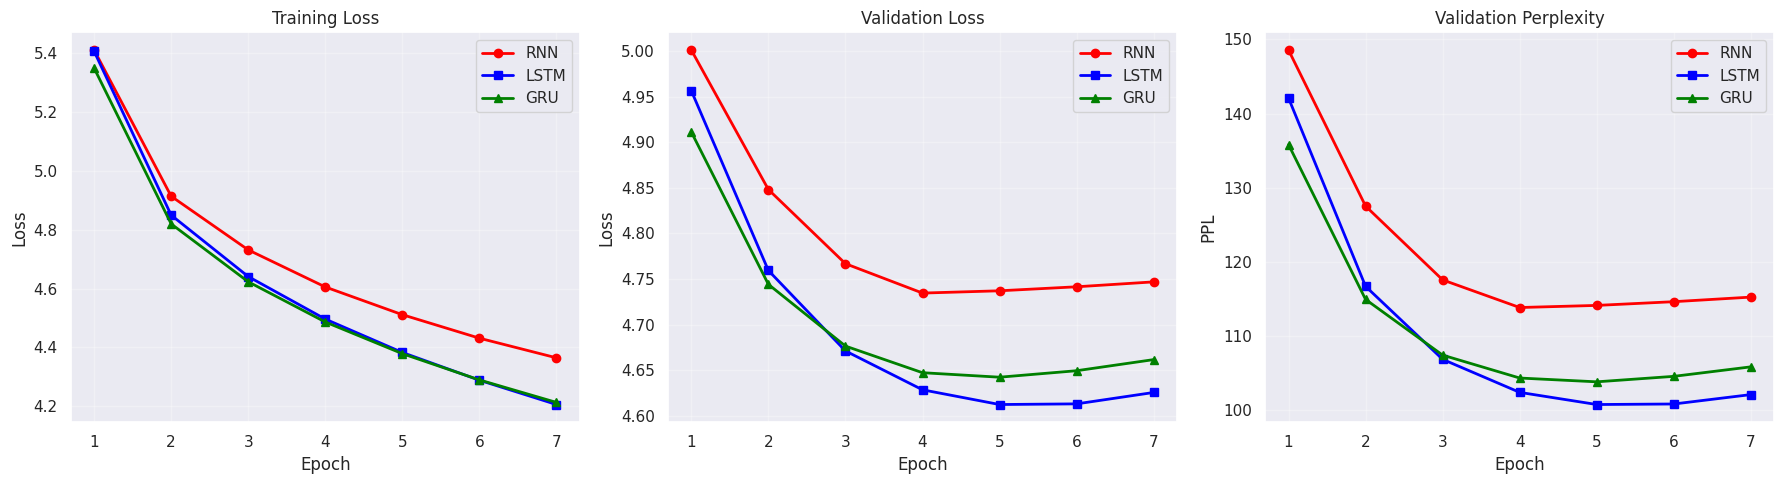

In [ ]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
experiment_1 = {
    'RNN': (losses_train, losses_val, np.exp(losses_val)),
    'LSTM': (losses_train_lstm, losses_val_lstm, np.exp(losses_val_lstm)),
    'GRU': (losses_train_gru, losses_val_gru, np.exp(losses_val_gru))
}
markers = {'RNN': 'o', 'LSTM': 's', 'GRU': '^'}
colors = {'RNN': 'red',
          'LSTM': 'blue',
          'GRU': 'green'}
for name, (train, _, _) in experiment_1.items():
    axes[0].plot(epochs, train, marker=markers[name], color=colors[name], label=name, linewidth=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for name, (_, val, _) in experiment_1.items():
    axes[1].plot(epochs, val, marker=markers[name], color=colors[name], label=name, linewidth=2)
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for name, (_, _, ppls) in experiment_1.items():
    axes[2].plot(epochs, ppls, marker=markers[name], label=name, color=colors[name], linewidth=2)
axes[2].set_title('Validation Perplexity')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('PPL')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Таким образом, модель с обычными RNN слоями показала результаты намного хуже: медленная сходимость, быстрое переобучение

Лучшие результаты достигла модель LSTM с перплексией 101.27 на валидации

In [ ]:
test_loss, test_perp = evaluate(model_lstm, criterion, test_dataloader)

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

In [ ]:
print(f'Test Perplexity: {test_perp}')

Test Perplexity: 102.32249719668657


Далее будем использовать модель с LSTM слоями

### Второй эксперимент (2 балла)

В этом эксперименте посмотрим, как повлияет на качество количество LSTM слоев. Также добавим регуляризацию между LSTM слоями

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
def train_model(model, train_dataloader, val_dataloader, criterion, optimizer, max_epochs, device, sheduler=None, max_norm=None):
  model = model.to(device)
  losses_train = []
  losses_val = []
  perplexities = []
  best_model = None
  best_val_loss = float('inf')
  for epoch in range(max_epochs):
      train_loss = train_one_epoch(model, train_dataloader, criterion, optimizer, device, max_norm=max_norm)
      val_loss, val_perp = evaluate(model, criterion, val_dataloader)
      print(f'Epoch {epoch+1}/{max_epochs}  Train Loss: {train_loss} | Val Loss: {val_loss} | Val Perplexity: {val_perp}')
      if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model
      losses_train.append(train_loss)
      losses_val.append(val_loss)
      perplexities.append(val_perp)
      if scheduler is not None:
          if isinstance(scheduler, ReduceLROnPlateau):
              scheduler.step(val_loss)
          else:
              scheduler.step()
  return best_model, losses_train, losses_val, perplexities

In [ ]:
model = LanguageModel(hidden_dim=256, vocab_size=len(vocab), rnn_type='lstm', num_layers=3)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs=7
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)
best_model, losses_train, losses_val, perplexities = train_model(
    model,
    train_dataloader,
    eval_dataloader,
    criterion,
    optimizer,
    max_epochs=num_epochs,
    device=device,
    sheduler=scheduler
    )

Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 1/7  Train Loss: 5.819788093444137 | Val Loss: 5.268018441322522 | Val Perplexity: 194.93077165652545


Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

...

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 6/7  Train Loss: 4.551865050606639 | Val Loss: 4.73263422648112 | Val Perplexity: 114.21975874289488


Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 7/7  Train Loss: 4.4664884710733865 | Val Loss: 4.710674273662078 | Val Perplexity: 111.74471190036871


In [ ]:
test_loss, test_perp = evaluate(best_model, criterion, test_dataloader)
print(f'Test Perplexity: {test_perp}')

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Test Perplexity: 112.98780221205492


In [ ]:
model = LanguageModel(hidden_dim=256, vocab_size=len(vocab), rnn_type='lstm', num_layers=2)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
num_epochs=7
best_model, losses_train, losses_val, perplexities = train_model(
    model,
    train_dataloader,
    eval_dataloader,
    criterion,
    optimizer,
    max_epochs=num_epochs,
    device=device
    )

Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 1/7  Train Loss: 5.557322804427204 | Val Loss: 5.0663812924654055 | Val Perplexity: 159.40841992696127


Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

...

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 6/7  Train Loss: 4.448272825150555 | Val Loss: 4.58358607842372 | Val Perplexity: 98.40397213666867


Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 7/7  Train Loss: 4.377607756819537 | Val Loss: 4.568050430371211 | Val Perplexity: 96.9044526907114


Лосс и перплексия стабильно падают, поэтому дообучим модель на еще 5 эпохах

In [ ]:
best_model, losses_train, losses_val, perplexities = train_model(
    model,
    train_dataloader,
    eval_dataloader,
    criterion,
    optimizer,
    max_epochs=5,
    device=device
    )

Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 1/5  Train Loss: 4.317735208202924 | Val Loss: 4.556967570231511 | Val Perplexity: 95.83653538043683


Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

...

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 4/5  Train Loss: 4.175374030683277 | Val Loss: 4.5568258456694775 | Val Perplexity: 95.87174474276028


Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 5/5  Train Loss: 4.137768764603263 | Val Loss: 4.558361288828728 | Val Perplexity: 96.03197596623347


In [ ]:
test_loss, test_perp = evaluate(best_model, criterion, test_dataloader)
print(f'Test Perplexity: {test_perp}')

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Test Perplexity: 95.20819214062813


# Третий эксперимент

Попробуем улучшить архитектуру модели:
- LayerNorm
- dropout на уровне эмбеддингов
- Добавим связывание весов
- Инициализация весов

Что осталь с предыдущего эксперимента:
- Используем также LSTM слои
- Регуляризация между LSTM слоями
- num_layers=2

In [ ]:
class ImprovedLanguageModel(nn.Module):
    def __init__(self, vocab_size, hidden_dim, num_layers=2, rnn_type='lstm', dropout=0.3, tie_weights=True):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.tie_weights = tie_weights

        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.embed_dropout = nn.Dropout(dropout)

        rnn_kwargs = dict(input_size=hidden_dim, hidden_size=hidden_dim,
                          num_layers=num_layers, batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)

        if rnn_type == 'lstm':
            self.rnn = nn.LSTM(**rnn_kwargs)
        elif rnn_type == 'gru':
            self.rnn = nn.GRU(**rnn_kwargs)
        else:
            self.rnn = nn.RNN(**rnn_kwargs)

        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.decoder = nn.Linear(hidden_dim, vocab_size, bias=True)

        if tie_weights:
            self.decoder.weight = self.embedding.weight
        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        nn.init.zeros_(self.decoder.bias)
        if not self.tie_weights:
            nn.init.uniform_(self.decoder.weight, -initrange, initrange)

        for name, param in self.rnn.named_parameters():
            if 'weight' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

    def forward(self, input_ids: torch.Tensor):
        emb = self.embed_dropout(self.embedding(input_ids))
        output, _ = self.rnn(emb)
        output = self.layer_norm(output)
        output = self.dropout(output)
        return self.decoder(output)

In [ ]:
model = ImprovedLanguageModel(hidden_dim=256, vocab_size=len(vocab), rnn_type='lstm', num_layers=2)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
num_epochs=7
best_model, losses_train, losses_val, perplexities = train_model(
    model,
    train_dataloader,
    eval_dataloader,
    criterion,
    optimizer,
    max_epochs=num_epochs,
    device=device
    )

Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 1/7  Train Loss: 5.3883399069549 | Val Loss: 4.880550014667022 | Val Perplexity: 132.3453897818541


Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

...

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 6/7  Train Loss: 4.413004409470869 | Val Loss: 4.473027923168281 | Val Perplexity: 88.06596702184433


Обучение:   0%|          | 0/1243 [00:00<?, ?it/s]

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 7/7  Train Loss: 4.3587953808416975 | Val Loss: 4.4606588528706475 | Val Perplexity: 86.98778098668808


In [ ]:
test_loss, test_perp = evaluate(best_model, criterion, test_dataloader)
print(f'Test Perplexity: {test_perp}')

Валидация:   0%|          | 0/156 [00:00<?, ?it/s]

Test Perplexity: 86.28913669097118


Перплексия и лосс продолжают падать, модель еще недообучена, однако уже получила наилучшую метрику. Посмотрим, какой текст она может сгенерировать

In [ ]:
def generate_simple(model, max_len=30, temp=0.8):
    device = next(model.parameters()).device
    model.eval()
    x = torch.tensor([[word2ind['<bos>']]], dtype=torch.long).to(device)
    res = []

    with torch.no_grad():
        for _ in range(max_len):
            logits = model(x)[0, -1] / temp
            next_id = torch.multinomial(torch.softmax(logits, -1), 1).item()

            if next_id == word2ind['<eos>']:
                break

            res.append(ind2word[next_id])
            x = torch.cat([x, torch.tensor([[next_id]], device=device)], dim=1)

    return " ".join(res)

In [ ]:
generate_simple(best_model, max_len=25, temp=0.7)

'Everyone really is a great actor who has done it with a few laughs .'

### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

| Experiment | Model | Key Changes | Best Val PPL | Test PPL | Notes |
|------------|-------|-------------|--------------|----------|-------|
| Exp1: RNN types | RNN | hidden_dim=256, 1 layer, dropout=0.3 | 114.40 | — | Переобучение после epoch 4 |
| Exp1: RNN types | LSTM | hidden_dim=256, 1 layer, dropout=0.3 | **101.27** | **102.32** |  Лучшая модель, стабильная сходимость |
| Exp1: RNN types | GRU | hidden_dim=256, 1 layer, dropout=0.3 | 104.38 | — | Хуже LSTM |
||
| Exp2: +2 layers |LSTM| num_layers=2, lstm_dropout=0.3, weight_decay| 95.30|**95.21** | Увеличение слоев улучшает качество, работает только с dropout между слоями|
||
| Exp3: Architecture |LSTM | LayerNorm, embedding dropout, weight tying, orthogonal init + exp2|86.99|**86.29**|Лучший результат, лосс монотонно падает |

Для увеличения качества генерации можно пересмотреть преобработку (увеличить окно контекста, привести к единому регистру, увеличить размер словаря), однако время обучения и объяем занимаемой памяти сильно увеличатся. Также можно использовать более сложные модели (например, трансформеры)